# Clusterização de Filiais

Este notebook usa os checkpoints da `Base_V2` para segmentar as filiais.

A matriz oficial de clusterização é `features_filiais_cluster_semana_dia_V2.parquet`, com features gerais da filial e ratios `semana_mes x dia_semana_num`. As bases experimentais A/C e os resumos auxiliares deixaram de ser arquivos de entrada; se forem necessários novamente, devem ser recriados no notebook `Bases_cluster`.

Aqui testamos KMeans e Agglomerative Clustering para diferentes valores de `k`, tratamos a filial `1521` como cluster especial de alto volume e validamos os clusters na base diária.

No final, salvamos somente os checkpoints finais de cluster:

- `cluster_filial_modelagem_V2.parquet`
- `perfil_clusters_V2.parquet`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score


BASE_V2 = Path.cwd() / "Base_V2"

ARQUIVOS_ENTRADA = {
    "features_diarias": "features_filiais_diarias_V2.parquet",
    "features_agregadas": "features_filiais_agregadas_V2.parquet",
    "base_b_semana_dia": "features_filiais_cluster_semana_dia_V2.parquet",
}

DESCRICAO_BASES = {
    "base_b_semana_dia": "Features gerais + ratios semana x dia",
}

CHECKPOINTS_CLUSTER = {
    "cluster_filial_modelagem": "cluster_filial_modelagem_V2.parquet",
    "perfil_clusters": "perfil_clusters_V2.parquet",
}

K_TESTES = range(2, 9)
RANDOM_STATE = 42
TAMANHO_MINIMO_CLUSTER = 5
FILIAIS_CLUSTER_ESPECIAL = ["1521"]

PALETA = {
    "azul": "#2563EB",
    "laranja": "#F97316",
    "verde": "#16A34A",
    "vermelho": "#DC2626",
    "roxo": "#7C3AED",
    "cinza": "#4B5563",
    "cinza_claro": "#E5E7EB",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#374151",
    "axes.titlecolor": "#111827",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size": 10,
    "legend.frameon": False,
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
})


## Ler checkpoints da V2

Carrega a base diária, a base agregada e a matriz oficial de clusterização.


In [2]:
def limpar_eixo(ax, grade="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grade, color=PALETA["cinza_claro"], linewidth=0.8)
    ax.set_axisbelow(True)


def dividir_seguro(numerador, denominador):
    numerador = pd.Series(numerador)
    denominador = pd.Series(denominador)
    resultado = numerador.div(denominador.replace(0, np.nan))
    return resultado.replace([np.inf, -np.inf], np.nan).fillna(0)


def ler_base_v2():
    bases = {}
    faltando = []

    for nome, arquivo in ARQUIVOS_ENTRADA.items():
        caminho = BASE_V2 / arquivo
        if caminho.exists():
            bases[nome] = pd.read_parquet(caminho)
        else:
            faltando.append(str(caminho))

    if faltando:
        raise FileNotFoundError("Arquivos nao encontrados:\n- " + "\n- ".join(faltando))

    return bases


bases = ler_base_v2()
features_diarias = bases["features_diarias"].copy()
features_agregadas = bases["features_agregadas"].copy()
matrizes_cluster = {
    nome: bases[nome].copy()
    for nome in DESCRICAO_BASES
}

resumo_leitura = []
for nome, matriz in matrizes_cluster.items():
    colunas_features = [coluna for coluna in matriz.columns if coluna != "codigo_filial"]
    resumo_leitura.append({
        "base_cluster": nome,
        "descricao": DESCRICAO_BASES[nome],
        "filiais": matriz["codigo_filial"].nunique(),
        "features": len(colunas_features),
        "nulos": int(matriz[colunas_features].isna().sum().sum()),
        "features_num": len([coluna for coluna in colunas_features if coluna.startswith("num__")]),
        "features_cat": len([coluna for coluna in colunas_features if coluna.startswith("cat__")]),
        "features_pc_ratio": len([coluna for coluna in colunas_features if coluna.startswith("pc_ratio_")]),
        "features_ratio_semana": len([coluna for coluna in colunas_features if coluna.startswith("ratio_semana_dia__")]),
        "features_ratio_mensal": len([coluna for coluna in colunas_features if coluna.startswith("ratio_mensal__")]),
    })

resumo_leitura = pd.DataFrame(resumo_leitura)

resumo_diaria = pd.DataFrame({
    "base": ["features_diarias", "features_agregadas"],
    "linhas": [features_diarias.shape[0], features_agregadas.shape[0]],
    "colunas": [features_diarias.shape[1], features_agregadas.shape[1]],
    "filiais": [
        features_diarias["codigo_filial"].nunique(),
        features_agregadas["codigo_filial"].nunique(),
    ],
})

display(resumo_leitura)
display(resumo_diaria)


,base_cluster,descricao,filiais,features,nulos,features_num,features_cat,features_pc_ratio,features_ratio_semana,features_ratio_mensal
0,base_a_pca_mes_semana_dia,Features gerais + PCA das ratios mes x semana ...,100,111,0,37,17,57,0,0
1,base_b_semana_dia,Features gerais + ratios semana x dia,100,89,0,37,17,0,35,0
2,base_c_semana_dia_mes,Features gerais + ratios semana x dia + ratios...,100,101,0,37,17,0,35,12


,base,linhas,colunas,filiais
0,features_diarias,73082,80,100
1,features_agregadas,100,43,100


## Funções de clusterização

Para a matriz oficial, rodamos KMeans e Agglomerative Clustering em `k=2` até `k=8`. A comparação agora é entre algoritmos, quantidade de clusters e escopo com/sem outliers métricos.


In [3]:
def calcular_metricas(X, labels):
    return {
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
    }


def avaliar_clusterizacao(X, codigos_filiais, base_cluster, escopo, prefixo_coluna, k_testes=K_TESTES):
    metricas = []
    labels_por_k = pd.DataFrame({"codigo_filial": codigos_filiais})

    for k in k_testes:
        modelos = {
            "kmeans": KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50),
            "agglomerative": AgglomerativeClustering(n_clusters=k, linkage="ward"),
        }

        for nome_modelo, modelo in modelos.items():
            labels = modelo.fit_predict(X)
            coluna_cluster = f"cluster_{prefixo_coluna}_{nome_modelo}_k{k}"
            labels_por_k[coluna_cluster] = labels

            contagem = pd.Series(labels).value_counts()
            metricas_modelo = calcular_metricas(X, labels)
            metricas.append({
                "base_cluster": base_cluster,
                "descricao_base": DESCRICAO_BASES[base_cluster],
                "escopo": escopo,
                "modelo": nome_modelo,
                "k": k,
                "coluna_cluster": coluna_cluster,
                "qtd_clusters": pd.Series(labels).nunique(),
                "menor_cluster": contagem.min(),
                "maior_cluster": contagem.max(),
                **metricas_modelo,
            })

    return pd.DataFrame(metricas), labels_por_k


def identificar_outliers_singleton(labels_base_completa, prefixo_coluna):
    colunas_k2 = [
        coluna for coluna in labels_base_completa.columns
        if coluna.startswith(f"cluster_{prefixo_coluna}_") and coluna.endswith("_k2")
    ]

    conjuntos_outliers = []
    for coluna in colunas_k2:
        contagem = labels_base_completa[coluna].value_counts()
        clusters_unitarios = contagem[contagem.eq(1)].index
        codigos = set(
            labels_base_completa.loc[
                labels_base_completa[coluna].isin(clusters_unitarios),
                "codigo_filial",
            ].astype(str)
        )
        if codigos:
            conjuntos_outliers.append(codigos)

    if not conjuntos_outliers:
        return []

    return sorted(set.intersection(*conjuntos_outliers))


def escolher_melhor(metricas):
    candidatas = metricas[
        metricas["escopo"].eq("sem_outliers")
        & metricas["menor_cluster"].ge(TAMANHO_MINIMO_CLUSTER)
    ].copy()

    if candidatas.empty:
        candidatas = metricas[metricas["menor_cluster"].ge(TAMANHO_MINIMO_CLUSTER)].copy()

    if candidatas.empty:
        candidatas = metricas.copy()

    return (
        candidatas.sort_values(
            ["silhouette", "davies_bouldin", "calinski_harabasz"],
            ascending=[False, True, False],
        )
        .iloc[0]
    )


def rodar_experimento_base(base_cluster, matriz):
    prefixo = base_cluster.replace("base_", "")
    colunas_features = [coluna for coluna in matriz.columns if coluna != "codigo_filial"]
    X = matriz[colunas_features].to_numpy(dtype=float)

    metricas_completa, labels_completa = avaliar_clusterizacao(
        X,
        matriz["codigo_filial"],
        base_cluster=base_cluster,
        escopo="base_completa",
        prefixo_coluna=prefixo,
    )
    outliers = identificar_outliers_singleton(labels_completa, prefixo)

    if outliers:
        mascara_core = ~matriz["codigo_filial"].astype(str).isin(outliers)
    else:
        mascara_core = pd.Series(True, index=matriz.index)

    matriz_core = matriz.loc[mascara_core].copy()
    X_core = matriz_core[colunas_features].to_numpy(dtype=float)

    metricas_core, labels_core = avaliar_clusterizacao(
        X_core,
        matriz_core["codigo_filial"],
        base_cluster=base_cluster,
        escopo="sem_outliers",
        prefixo_coluna=f"{prefixo}_core",
    )

    metricas = pd.concat([metricas_completa, metricas_core], ignore_index=True)
    labels = labels_completa.merge(labels_core, on="codigo_filial", how="left")
    melhor = escolher_melhor(metricas)
    melhor["outliers_detectados"] = ", ".join(outliers) if outliers else "nenhum"
    melhor["qtd_outliers_detectados"] = len(outliers)

    return metricas, labels, melhor, outliers


## Rodar experimentos

Executa as combinações de algoritmo, `k` e escopo, guardando métricas e rótulos de cluster para comparação.


In [4]:
metricas_lista = []
labels_lista = []
melhores_lista = []
outliers_por_base = {}

for nome_base, matriz in matrizes_cluster.items():
    metricas_base, labels_base, melhor_base, outliers_base = rodar_experimento_base(nome_base, matriz)
    metricas_lista.append(metricas_base)
    labels_lista.append(labels_base)
    melhores_lista.append(melhor_base)
    outliers_por_base[nome_base] = outliers_base

metricas_cluster = pd.concat(metricas_lista, ignore_index=True)
labels_por_k = labels_lista[0]
for labels_base in labels_lista[1:]:
    labels_por_k = labels_por_k.merge(labels_base, on="codigo_filial", how="outer")

resumo_bases = pd.DataFrame(melhores_lista).reset_index(drop=True)
melhor_referencia = escolher_melhor(resumo_bases)

display(metricas_cluster.sort_values(["base_cluster", "escopo", "modelo", "k"]))
display(resumo_bases[[
    "base_cluster",
    "descricao_base",
    "escopo",
    "modelo",
    "k",
    "menor_cluster",
    "maior_cluster",
    "silhouette",
    "davies_bouldin",
    "calinski_harabasz",
    "outliers_detectados",
]])
display(pd.DataFrame(melhor_referencia).T)


,base_cluster,descricao_base,escopo,modelo,k,coluna_cluster,qtd_clusters,menor_cluster,maior_cluster,silhouette,calinski_harabasz,davies_bouldin
1,base_a_pca_mes_semana_dia,Features gerais + PCA das ratios mes x semana ...,base_completa,agglomerative,2,cluster_a_pca_mes_semana_dia_agglomerative_k2,2,1,99,0.558599,9.299783,0.316719
3,base_a_pca_mes_semana_dia,Features gerais + PCA das ratios mes x semana ...,base_completa,agglomerative,3,cluster_a_pca_mes_semana_dia_agglomerative_k3,3,1,83,0.134930,8.350193,1.985722
5,base_a_pca_mes_semana_dia,Features gerais + PCA das ratios mes x semana ...,base_completa,agglomerative,4,cluster_a_pca_mes_semana_dia_agglomerative_k4,4,1,83,0.113309,7.555558,1.634432
7,base_a_pca_mes_semana_dia,Features gerais + PCA das ratios mes x semana ...,base_completa,agglomerative,5,cluster_a_pca_mes_semana_dia_agglomerative_k5,5,1,52,0.040487,6.978808,2.449910
9,base_a_pca_mes_semana_dia,Features gerais + PCA das ratios mes x semana ...,base_completa,agglomerative,6,cluster_a_pca_mes_semana_dia_agglomerative_k6,6,1,52,0.023906,6.556889,2.283082
...,...,...,...,...,...,...,...,...,...,...,...,...
74,base_c_semana_dia_mes,Features gerais + ratios semana x dia + ratios...,sem_outliers,kmeans,4,cluster_c_semana_dia_mes_core_kmeans_k4,4,1,82,0.311345,18.445451,0.922416
76,base_c_semana_dia_mes,Features gerais + ratios semana x dia + ratios...,sem_outliers,kmeans,5,cluster_c_semana_dia_mes_core_kmeans_k5,5,1,50,0.151303,17.266404,1.639703
78,base_c_semana_dia_mes,Features gerais + ratios semana x dia + ratios...,sem_outliers,kmeans,6,cluster_c_semana_dia_mes_core_kmeans_k6,6,1,42,0.113416,15.997882,1.656843
80,base_c_semana_dia_mes,Features gerais + ratios semana x dia + ratios...,sem_outliers,kmeans,7,cluster_c_semana_dia_mes_core_kmeans_k7,7,1,32,0.106301,15.022349,1.679855


,base_cluster,descricao_base,escopo,modelo,k,menor_cluster,maior_cluster,silhouette,davies_bouldin,calinski_harabasz,outliers_detectados
0,base_a_pca_mes_semana_dia,Features gerais + PCA das ratios mes x semana ...,sem_outliers,agglomerative,2,16,83,0.136293,2.818834,6.845856,1521
1,base_b_semana_dia,Features gerais + ratios semana x dia,sem_outliers,kmeans,3,8,81,0.347178,1.378293,21.223176,nenhum
2,base_c_semana_dia_mes,Features gerais + ratios semana x dia + ratios...,sem_outliers,kmeans,2,11,89,0.301037,1.248165,19.250216,nenhum


,base_cluster,descricao_base,escopo,modelo,k,coluna_cluster,qtd_clusters,menor_cluster,maior_cluster,silhouette,calinski_harabasz,davies_bouldin,outliers_detectados,qtd_outliers_detectados
1,base_b_semana_dia,Features gerais + ratios semana x dia,sem_outliers,kmeans,3,cluster_b_semana_dia_core_kmeans_k3,3,8,81,0.347178,21.223176,1.378293,nenhum,0


## Comparar métricas do experimento

Compara Silhouette, Calinski-Harabasz e Davies-Bouldin para escolher uma solução equilibrada entre qualidade estatística e interpretabilidade.


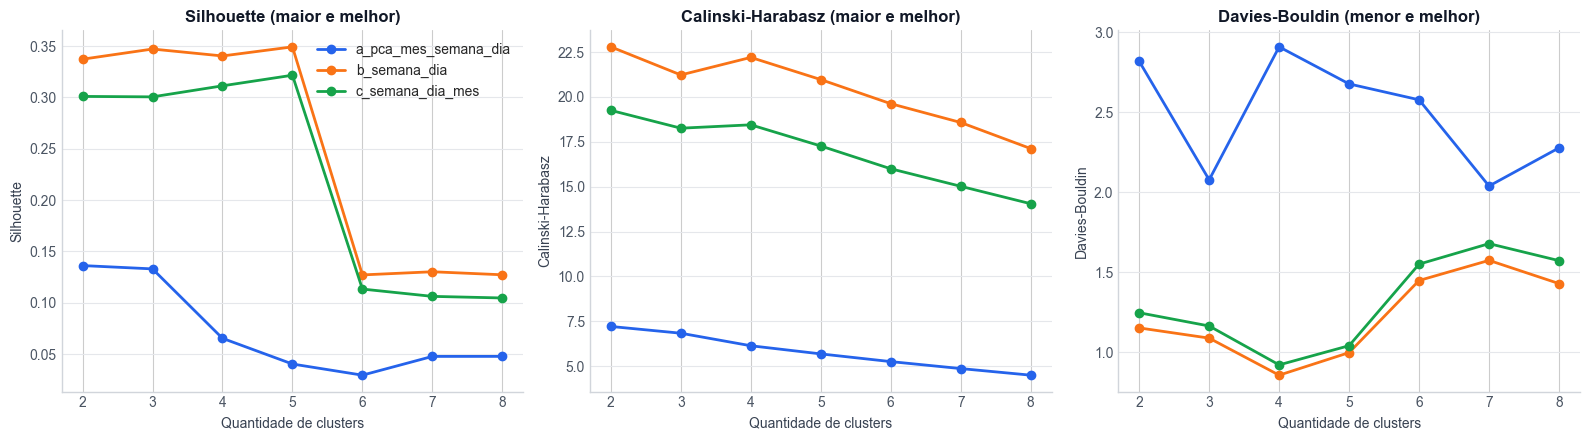

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

metricas_plot = [
    ("silhouette", "Silhouette", "maior e melhor"),
    ("calinski_harabasz", "Calinski-Harabasz", "maior e melhor"),
    ("davies_bouldin", "Davies-Bouldin", "menor e melhor"),
]

cores = {
    "base_b_semana_dia": PALETA["laranja"],
}

metricas_plot_base = metricas_cluster[metricas_cluster["escopo"].eq("sem_outliers")].copy()

for ax, (metrica, titulo, subtitulo) in zip(axes, metricas_plot):
    for nome_base, dados in metricas_plot_base.groupby("base_cluster"):
        dados_modelo = (
            dados.sort_values(["k", metrica], ascending=[True, metrica == "davies_bouldin"])
            .groupby("k", as_index=False)
            .head(1)
            .sort_values("k")
        )
        ax.plot(
            dados_modelo["k"],
            dados_modelo[metrica],
            marker="o",
            linewidth=2,
            color=cores.get(nome_base, PALETA["cinza"]),
            label=nome_base.replace("base_", ""),
        )

    ax.set_title(f"{titulo} ({subtitulo})")
    ax.set_xlabel("Quantidade de clusters")
    ax.set_ylabel(titulo)
    ax.set_xticks(list(K_TESTES))
    limpar_eixo(ax)

axes[0].legend()
plt.tight_layout()
plt.show()


## Visualizar melhor solução em 2D

Para visualização, projetamos a matriz em 2 componentes com PCA apenas para plot. Isso não altera os clusters salvos.


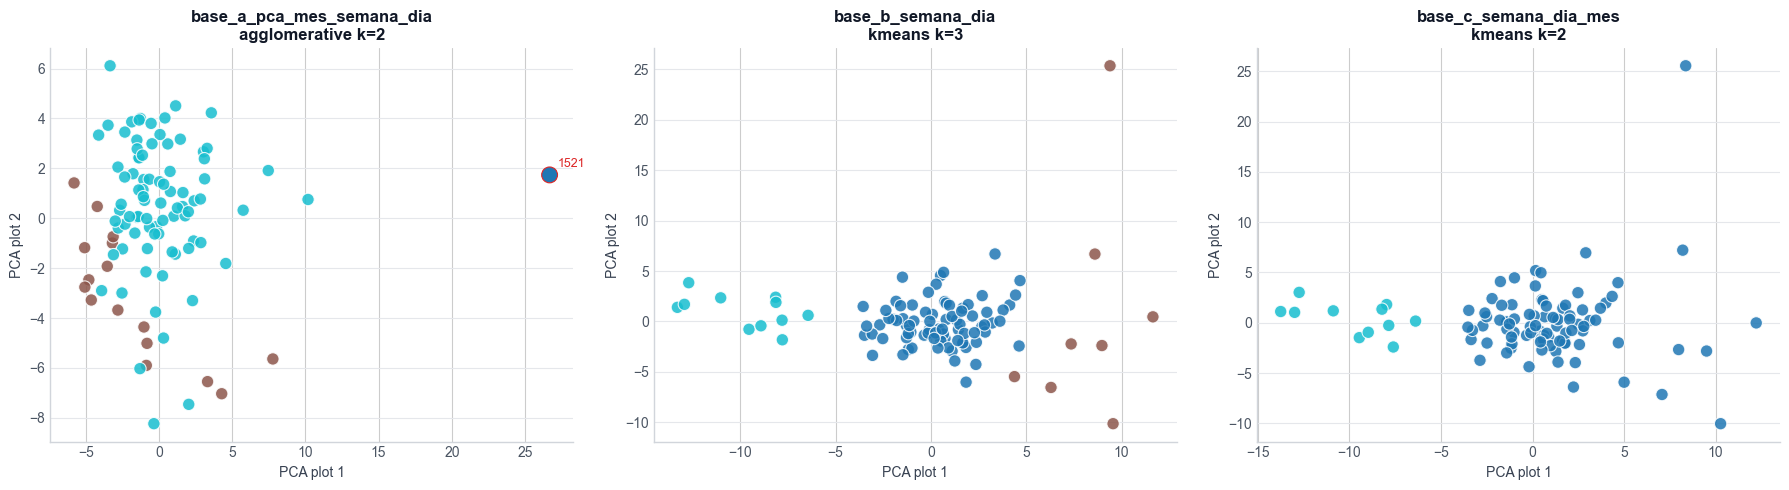

In [6]:
n_bases = len(resumo_bases)
fig, axes = plt.subplots(1, n_bases, figsize=(max(6, 6 * n_bases), 5))
axes = np.atleast_1d(axes)

for ax, (_, linha) in zip(axes, resumo_bases.iterrows()):
    nome_base = linha["base_cluster"]
    coluna_cluster = linha["coluna_cluster"]
    matriz = matrizes_cluster[nome_base]
    colunas_features = [coluna for coluna in matriz.columns if coluna != "codigo_filial"]
    X_plot = matriz[colunas_features].to_numpy(dtype=float)
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_plot)

    dados_plot = pd.DataFrame({
        "codigo_filial": matriz["codigo_filial"].astype(str).values,
        "pc_plot_1": coords[:, 0],
        "pc_plot_2": coords[:, 1],
    }).merge(labels_por_k[["codigo_filial", coluna_cluster]], on="codigo_filial", how="left")

    labels_plot = dados_plot[coluna_cluster].fillna(-1)
    ax.scatter(
        dados_plot["pc_plot_1"],
        dados_plot["pc_plot_2"],
        c=labels_plot,
        cmap="tab10",
        s=np.where(labels_plot.eq(-1), 130, 80),
        alpha=np.where(labels_plot.eq(-1), 1.0, 0.85),
        edgecolor=np.where(labels_plot.eq(-1), PALETA["vermelho"], "white"),
        linewidth=0.8,
    )

    for _, filial in dados_plot.loc[labels_plot.eq(-1)].iterrows():
        ax.annotate(
            filial["codigo_filial"],
            (filial["pc_plot_1"], filial["pc_plot_2"]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9,
            color=PALETA["vermelho"],
        )

    ax.set_title(f"{nome_base}\n{linha['modelo']} k={int(linha['k'])}")
    ax.set_xlabel("PCA plot 1")
    ax.set_ylabel("PCA plot 2")
    limpar_eixo(ax)

plt.tight_layout()
plt.show()


## Perfil dos clusters da referência

A referência final é escolhida dentro da matriz oficial, priorizando `sem_outliers`, `menor_cluster >= 5`, maior `silhouette` e menor `davies_bouldin`.


In [7]:
BASE_REFERENCIA = melhor_referencia["base_cluster"]
MODELO_REFERENCIA = melhor_referencia["modelo"]
ESCOPO_REFERENCIA = melhor_referencia["escopo"]
K_REFERENCIA = int(melhor_referencia["k"])
COLUNA_CLUSTER_REFERENCIA = melhor_referencia["coluna_cluster"]
OUTLIERS_REFERENCIA = outliers_por_base.get(BASE_REFERENCIA, [])

filiais_clusterizadas = features_agregadas.merge(labels_por_k, on="codigo_filial", how="left").copy()
filiais_clusterizadas["cluster_referencia_base"] = BASE_REFERENCIA
filiais_clusterizadas["cluster_referencia_modelo"] = MODELO_REFERENCIA
filiais_clusterizadas["cluster_referencia_escopo"] = ESCOPO_REFERENCIA
filiais_clusterizadas["cluster_referencia_k"] = K_REFERENCIA
filiais_clusterizadas["cluster_referencia_original"] = (
    filiais_clusterizadas[COLUNA_CLUSTER_REFERENCIA]
    .fillna(-1)
    .astype(int)
)

mascara_cluster_especial = filiais_clusterizadas["codigo_filial"].astype(str).isin(FILIAIS_CLUSTER_ESPECIAL)
filiais_clusterizadas["flag_outlier_cluster"] = mascara_cluster_especial.astype(int)
filiais_clusterizadas["cluster_referencia"] = filiais_clusterizadas["cluster_referencia_original"]
filiais_clusterizadas.loc[mascara_cluster_especial, "cluster_referencia"] = -1
filiais_clusterizadas["cluster_referencia"] = filiais_clusterizadas["cluster_referencia"].astype(int)

perfil_base_nomes = (
    filiais_clusterizadas.loc[~filiais_clusterizadas["cluster_referencia"].eq(-1)]
    .groupby("cluster_referencia", as_index=False)
    .agg(
        faturamento_bruto_medio_dia=("faturamento_bruto_medio_dia", "mean"),
        share_n_med_faturamento_total=("share_n_med_faturamento_total", "mean"),
    )
)

mapa_nome_cluster = {-1: "Atipica de alto volume"}
if not perfil_base_nomes.empty:
    cluster_alto_volume = int(perfil_base_nomes.nlargest(1, "faturamento_bruto_medio_dia")["cluster_referencia"].iloc[0])
    cluster_baixo_volume = int(perfil_base_nomes.nsmallest(1, "faturamento_bruto_medio_dia")["cluster_referencia"].iloc[0])

    for cluster_id in perfil_base_nomes["cluster_referencia"].astype(int):
        if cluster_id == cluster_alto_volume:
            mapa_nome_cluster[cluster_id] = "Alto volume e maior N-MED"
        elif cluster_id == cluster_baixo_volume:
            mapa_nome_cluster[cluster_id] = "Menores sensiveis a dias uteis"
        else:
            mapa_nome_cluster[cluster_id] = "Intermediarias estaveis"

filiais_clusterizadas["cluster_filial_id"] = filiais_clusterizadas["cluster_referencia"]
filiais_clusterizadas["cluster_filial_nome"] = filiais_clusterizadas["cluster_filial_id"].map(mapa_nome_cluster)
filiais_clusterizadas["cluster_filial_tipo"] = np.where(
    filiais_clusterizadas["cluster_filial_id"].eq(-1),
    "especial",
    "modelo",
)
filiais_clusterizadas["cluster_filial_base"] = BASE_REFERENCIA
filiais_clusterizadas["cluster_filial_modelo"] = MODELO_REFERENCIA
filiais_clusterizadas["cluster_filial_escopo"] = ESCOPO_REFERENCIA
filiais_clusterizadas["cluster_filial_k"] = K_REFERENCIA
filiais_clusterizadas["cluster_referencia_descricao"] = filiais_clusterizadas["cluster_filial_nome"]

perfil_clusters = (
    filiais_clusterizadas.groupby(["cluster_filial_id", "cluster_filial_nome", "cluster_filial_tipo"], as_index=False)
    .agg(
        qtd_filiais=("codigo_filial", "nunique"),
        faturamento_bruto_medio_dia=("faturamento_bruto_medio_dia", "mean"),
        faturamento_bruto_mediano_dia=("faturamento_bruto_mediano_dia", "mean"),
        ticket_medio_bruto_dia_medio=("ticket_medio_bruto_dia_medio", "mean"),
        cupons_medios_dia=("cupons_medios_dia", "mean"),
        metragem_area_venda=("metragem_area_venda", "mean"),
        share_med_faturamento_total=("share_med_faturamento_total", "mean"),
        share_n_med_faturamento_total=("share_n_med_faturamento_total", "mean"),
        cv_faturamento_bruto_dia=("cv_faturamento_bruto_dia", "mean"),
        ratio_calendario_medio=("faturamento_bruto_ratio_calendario_medio", "mean"),
        pct_outlier=("flag_outlier_cluster", "mean"),
    )
    .sort_values(["cluster_filial_id", "faturamento_bruto_medio_dia"], ascending=[True, False])
)
perfil_clusters.insert(0, "base_referencia", BASE_REFERENCIA)
perfil_clusters.insert(1, "modelo_referencia", MODELO_REFERENCIA)
perfil_clusters.insert(2, "escopo_referencia", ESCOPO_REFERENCIA)
perfil_clusters.insert(3, "k_referencia", K_REFERENCIA)

cluster_filial_modelagem = filiais_clusterizadas[[
    "codigo_filial",
    "cluster_filial_id",
    "cluster_filial_nome",
    "cluster_filial_tipo",
    "cluster_filial_base",
    "cluster_filial_modelo",
    "cluster_filial_escopo",
    "cluster_filial_k",
    "cluster_referencia_original",
    "flag_outlier_cluster",
]].copy()

resumo_referencia = pd.DataFrame({
    "indicador": [
        "base_referencia",
        "modelo_referencia",
        "escopo_referencia",
        "k_referencia",
        "coluna_cluster_referencia",
        "silhouette_referencia",
        "davies_bouldin_referencia",
        "calinski_harabasz_referencia",
        "cluster_especial",
        "outliers_metricos_detectados",
    ],
    "valor": [
        BASE_REFERENCIA,
        MODELO_REFERENCIA,
        ESCOPO_REFERENCIA,
        K_REFERENCIA,
        COLUNA_CLUSTER_REFERENCIA,
        melhor_referencia["silhouette"],
        melhor_referencia["davies_bouldin"],
        melhor_referencia["calinski_harabasz"],
        ", ".join(FILIAIS_CLUSTER_ESPECIAL),
        ", ".join(OUTLIERS_REFERENCIA) if OUTLIERS_REFERENCIA else "nenhum",
    ],
})

display(resumo_referencia)
display(perfil_clusters)
display(
    filiais_clusterizadas
    .sort_values(["cluster_filial_id", "faturamento_bruto_medio_dia"], ascending=[True, False])
    [[
        "codigo_filial",
        "cluster_filial_id",
        "cluster_filial_nome",
        "cluster_filial_tipo",
        "cluster_referencia_original",
        "faturamento_bruto_medio_dia",
        "ticket_medio_bruto_dia_medio",
        "metragem_area_venda",
    ]]
    .head(30)
)


,indicador,valor
0,base_referencia,base_b_semana_dia
1,modelo_referencia,kmeans
2,escopo_referencia,sem_outliers
3,k_referencia,3
4,coluna_cluster_referencia,cluster_b_semana_dia_core_kmeans_k3
5,silhouette_referencia,0.347178
6,davies_bouldin_referencia,1.378293
7,calinski_harabasz_referencia,21.223176
8,cluster_especial,1521
9,outliers_metricos_detectados,nenhum


,base_referencia,modelo_referencia,escopo_referencia,k_referencia,cluster_filial_id,cluster_filial_nome,cluster_filial_tipo,qtd_filiais,faturamento_bruto_medio_dia,faturamento_bruto_mediano_dia,ticket_medio_bruto_dia_medio,cupons_medios_dia,metragem_area_venda,share_med_faturamento_total,share_n_med_faturamento_total,cv_faturamento_bruto_dia,ratio_calendario_medio,pct_outlier
0,base_b_semana_dia,kmeans,sem_outliers,3,-1,Atipica de alto volume,especial,1,386664.780876,376178.670000,704.98771,540.98632,1140.730600,0.643634,0.356366,0.394901,1.000045,1.0
1,base_b_semana_dia,kmeans,sem_outliers,3,0,Intermediarias estaveis,modelo,81,74479.682514,72414.646975,360.848552,203.578853,518.404696,0.655893,0.344107,0.375924,1.001642,0.0
2,base_b_semana_dia,kmeans,sem_outliers,3,1,Alto volume e maior N-MED,modelo,7,101241.493157,97451.475000,250.257516,384.188197,386.291771,0.546947,0.453053,0.305007,1.000745,0.0
3,base_b_semana_dia,kmeans,sem_outliers,3,2,Menores sensiveis a dias uteis,modelo,11,51089.238067,55031.294545,276.542589,167.551523,458.933836,0.661981,0.338019,0.565011,1.002049,0.0


,codigo_filial,cluster_filial_id,cluster_filial_nome,cluster_filial_tipo,cluster_referencia_original,faturamento_bruto_medio_dia,ticket_medio_bruto_dia_medio,metragem_area_venda
7,1521,-1,Atipica de alto volume,especial,1,386664.780876,704.98771,1140.7306
36,1614,0,Intermediarias estaveis,modelo,0,158991.250109,403.79784,580.9000
17,1554,0,Intermediarias estaveis,modelo,0,136364.509822,462.488529,683.7036
8,1524,0,Intermediarias estaveis,modelo,0,124117.743529,502.610422,500.2020
58,1689,0,Intermediarias estaveis,modelo,0,119611.539261,404.353258,521.7424
5,1515,0,Intermediarias estaveis,modelo,0,118542.232654,498.174528,592.8948
16,1551,0,Intermediarias estaveis,modelo,0,116249.898208,462.267088,392.5000
48,1656,0,Intermediarias estaveis,modelo,0,116116.156438,493.963608,702.1982
6,1518,0,Intermediarias estaveis,modelo,0,111511.354501,369.109331,462.6476
2,1506,0,Intermediarias estaveis,modelo,0,105839.825568,448.801961,521.2400


## Validar clusters na base diária

Depois de escolher a melhor configuração, voltamos para a base diária para verificar se os grupos realmente possuem comportamento diferente no tempo.

Vamos olhar:

- faturamento por dia da semana;
- faturamento por semana do mês;
- share MED/N-MED;
- comportamento de fim de semana;
- volatilidade mensal.


In [8]:
colunas_cluster_referencia = [
    "codigo_filial",
    "cluster_referencia_base",
    "cluster_referencia_modelo",
    "cluster_referencia_escopo",
    "cluster_referencia_k",
    "cluster_referencia",
    "cluster_referencia_descricao",
    "cluster_filial_id",
    "cluster_filial_nome",
    "cluster_filial_tipo",
    "flag_outlier_cluster",
]

diaria_cluster = features_diarias.merge(
    filiais_clusterizadas[colunas_cluster_referencia],
    on="codigo_filial",
    how="left",
)
diaria_cluster["tipo_dia"] = np.where(
    diaria_cluster["dia_semana_num"].isin([5, 6]),
    "fim_semana",
    "dia_util",
)
diaria_cluster["periodo_mes"] = pd.to_datetime(
    diaria_cluster["ano"].astype(str)
    + "-"
    + diaria_cluster["mes"].astype(str).str.zfill(2)
    + "-01"
)

chaves_cluster = [
    "cluster_filial_id",
    "cluster_filial_nome",
]

validacao_dia_semana = (
    diaria_cluster.groupby(chaves_cluster + ["dia_semana_num", "dia_semana"], as_index=False)
    .agg(
        qtd_filiais=("codigo_filial", "nunique"),
        qtd_dias=("data", "nunique"),
        faturamento_bruto_total=("faturamento_bruto_dia", "sum"),
        faturamento_bruto_medio_dia=("faturamento_bruto_dia", "mean"),
        cupons_medios_dia=("cupons_dia", "mean"),
        ticket_medio_bruto_dia=("ticket_medio_bruto_dia", "mean"),
    )
    .sort_values(["cluster_filial_id", "dia_semana_num"])
)

validacao_semana_mes = (
    diaria_cluster.groupby(chaves_cluster + ["semana_mes"], as_index=False)
    .agg(
        qtd_filiais=("codigo_filial", "nunique"),
        qtd_dias=("data", "nunique"),
        faturamento_bruto_total=("faturamento_bruto_dia", "sum"),
        faturamento_bruto_medio_dia=("faturamento_bruto_dia", "mean"),
        cupons_medios_dia=("cupons_dia", "mean"),
        ticket_medio_bruto_dia=("ticket_medio_bruto_dia", "mean"),
    )
    .sort_values(["cluster_filial_id", "semana_mes"])
)

validacao_mix_categoria = (
    diaria_cluster.groupby(chaves_cluster, as_index=False)
    .agg(
        qtd_filiais=("codigo_filial", "nunique"),
        faturamento_bruto_total=("faturamento_bruto_dia", "sum"),
        faturamento_med_total=("faturamento_med_dia", "sum"),
        faturamento_n_med_total=("faturamento_n_med_dia", "sum"),
        quantidade_total=("quantidade_dia", "sum"),
        quantidade_med_total=("quantidade_med_dia", "sum"),
        quantidade_n_med_total=("quantidade_n_med_dia", "sum"),
        share_med_faturamento_medio=("share_med_faturamento", "mean"),
        share_n_med_faturamento_medio=("share_n_med_faturamento", "mean"),
    )
)
validacao_mix_categoria["share_med_faturamento_total"] = dividir_seguro(
    validacao_mix_categoria["faturamento_med_total"],
    validacao_mix_categoria["faturamento_med_total"] + validacao_mix_categoria["faturamento_n_med_total"],
)
validacao_mix_categoria["share_n_med_faturamento_total"] = dividir_seguro(
    validacao_mix_categoria["faturamento_n_med_total"],
    validacao_mix_categoria["faturamento_med_total"] + validacao_mix_categoria["faturamento_n_med_total"],
)
validacao_mix_categoria["share_med_quantidade_total"] = dividir_seguro(
    validacao_mix_categoria["quantidade_med_total"],
    validacao_mix_categoria["quantidade_med_total"] + validacao_mix_categoria["quantidade_n_med_total"],
)
validacao_mix_categoria["share_n_med_quantidade_total"] = dividir_seguro(
    validacao_mix_categoria["quantidade_n_med_total"],
    validacao_mix_categoria["quantidade_med_total"] + validacao_mix_categoria["quantidade_n_med_total"],
)

validacao_fim_semana = (
    diaria_cluster.groupby(chaves_cluster + ["tipo_dia"], as_index=False)
    .agg(
        qtd_filiais=("codigo_filial", "nunique"),
        qtd_dias=("data", "nunique"),
        faturamento_bruto_total=("faturamento_bruto_dia", "sum"),
        faturamento_bruto_medio_dia=("faturamento_bruto_dia", "mean"),
        cupons_medios_dia=("cupons_dia", "mean"),
        ticket_medio_bruto_dia=("ticket_medio_bruto_dia", "mean"),
    )
    .sort_values(["cluster_filial_id", "tipo_dia"])
)

mensal_filial = (
    diaria_cluster.groupby(chaves_cluster + ["codigo_filial", "ano", "mes", "periodo_mes"], as_index=False)
    .agg(
        faturamento_bruto_mes=("faturamento_bruto_dia", "sum"),
        faturamento_bruto_medio_dia_mes=("faturamento_bruto_dia", "mean"),
        dias_com_venda=("teve_venda", "sum"),
        dias_periodo=("data", "nunique"),
    )
)

volatilidade_filial = (
    mensal_filial.groupby(chaves_cluster + ["codigo_filial"], as_index=False)
    .agg(
        meses_observados=("periodo_mes", "nunique"),
        faturamento_mensal_medio=("faturamento_bruto_mes", "mean"),
        faturamento_mensal_std=("faturamento_bruto_mes", "std"),
        faturamento_medio_dia_mensal_medio=("faturamento_bruto_medio_dia_mes", "mean"),
        faturamento_medio_dia_mensal_std=("faturamento_bruto_medio_dia_mes", "std"),
    )
)
volatilidade_filial["cv_faturamento_mensal"] = dividir_seguro(
    volatilidade_filial["faturamento_mensal_std"],
    volatilidade_filial["faturamento_mensal_medio"],
)
volatilidade_filial["cv_faturamento_medio_dia_mensal"] = dividir_seguro(
    volatilidade_filial["faturamento_medio_dia_mensal_std"],
    volatilidade_filial["faturamento_medio_dia_mensal_medio"],
)

validacao_volatilidade_mensal = (
    volatilidade_filial.groupby(chaves_cluster, as_index=False)
    .agg(
        qtd_filiais=("codigo_filial", "nunique"),
        meses_observados_medio=("meses_observados", "mean"),
        faturamento_mensal_medio=("faturamento_mensal_medio", "mean"),
        faturamento_mensal_std_medio=("faturamento_mensal_std", "mean"),
        cv_faturamento_mensal_medio=("cv_faturamento_mensal", "mean"),
        cv_faturamento_mensal_mediano=("cv_faturamento_mensal", "median"),
        cv_faturamento_medio_dia_mensal_medio=("cv_faturamento_medio_dia_mensal", "mean"),
    )
    .sort_values("cluster_filial_id")
)

pivot_dia_semana = validacao_dia_semana.pivot_table(
    index=["dia_semana_num", "dia_semana"],
    columns="cluster_filial_nome",
    values="faturamento_bruto_medio_dia",
    aggfunc="first",
)

pivot_semana_mes = validacao_semana_mes.pivot_table(
    index="semana_mes",
    columns="cluster_filial_nome",
    values="faturamento_bruto_medio_dia",
    aggfunc="first",
)

display(pivot_dia_semana)
display(validacao_dia_semana)
display(pivot_semana_mes)
display(validacao_semana_mes)
display(validacao_mix_categoria)
display(validacao_fim_semana)
display(validacao_volatilidade_mensal)


,cluster_filial_nome,Alto volume e maior N-MED,Atipica de alto volume,Intermediarias estaveis,Menores sensiveis a dias uteis
dia_semana_num,dia_semana,,,,
0,segunda-feira,95727.571413,479295.579048,81170.566320,64219.263060
1,terca-feira,97452.860231,459095.660000,81993.769745,63388.528883
2,quarta-feira,98314.070435,435120.867143,81341.033633,62554.453065
3,quinta-feira,102473.151538,421443.507885,80012.238196,60488.587500
4,sexta-feira,114218.182885,406770.960962,81244.379600,62116.052972
5,sabado,120567.918104,253948.838269,66523.104729,39555.927413
6,domingo,80112.823283,248924.997404,48876.533317,5040.946477


,cluster_filial_id,cluster_filial_nome,dia_semana_num,dia_semana,qtd_filiais,qtd_dias,faturamento_bruto_total,faturamento_bruto_medio_dia,cupons_medios_dia,ticket_medio_bruto_dia
0,-1,Atipica de alto volume,0,segunda-feira,1,105,5.032604e+07,479295.579048,618.219048,774.52762
1,-1,Atipica de alto volume,1,terca-feira,1,105,4.820504e+07,459095.660000,596.07619,770.566138
2,-1,Atipica de alto volume,2,quarta-feira,1,105,4.568769e+07,435120.867143,590.047619,737.416453
3,-1,Atipica de alto volume,3,quinta-feira,1,104,4.383012e+07,421443.507885,587.355769,716.346315
4,-1,Atipica de alto volume,4,sexta-feira,1,104,4.230418e+07,406770.960962,559.576923,728.669739
5,-1,Atipica de alto volume,5,sabado,1,104,2.641068e+07,253948.838269,408.865385,620.115791
6,-1,Atipica de alto volume,6,domingo,1,104,2.588820e+07,248924.997404,425.019231,585.660886
7,0,Intermediarias estaveis,0,segunda-feira,81,105,6.900310e+08,81170.566320,212.585461,377.280076
8,0,Intermediarias estaveis,1,terca-feira,81,105,6.973570e+08,81993.769745,215.617989,376.595492
9,0,Intermediarias estaveis,2,quarta-feira,81,105,6.918055e+08,81341.033633,215.66749,372.875542


cluster_filial_nome,Alto volume e maior N-MED,Atipica de alto volume,Intermediarias estaveis,Menores sensiveis a dias uteis
semana_mes,,,,
1,100927.683256,402665.749524,75639.308398,52145.974723
2,101973.519770,381319.951012,74447.366151,51633.453323
3,100414.025859,391839.051905,72612.429860,49857.665574
4,100697.958844,376488.786071,74327.446969,50251.164031
5,104133.225472,370564.073729,77026.790607,52440.429846


,cluster_filial_id,cluster_filial_nome,semana_mes,qtd_filiais,qtd_dias,faturamento_bruto_total,faturamento_bruto_medio_dia,cupons_medios_dia,ticket_medio_bruto_dia
0,-1,Atipica de alto volume,1,1,168,6.764785e+07,402665.749524,554.345238,715.167291
1,-1,Atipica de alto volume,2,1,168,6.406175e+07,381319.951012,545.089286,691.227482
2,-1,Atipica de alto volume,3,1,168,6.582896e+07,391839.051905,526.184524,734.59687
3,-1,Atipica de alto volume,4,1,168,6.325012e+07,376488.786071,535.357143,692.174336
4,-1,Atipica de alto volume,5,1,59,2.186328e+07,370564.073729,549.440678,667.358167
5,0,Intermediarias estaveis,1,81,168,1.028997e+09,75639.308398,205.850044,362.607498
6,0,Intermediarias estaveis,2,81,168,1.013080e+09,74447.366151,204.884259,359.444215
7,0,Intermediarias estaveis,3,81,168,9.881099e+08,72612.429860,201.125441,356.586333
8,0,Intermediarias estaveis,4,81,168,1.011448e+09,74327.446969,201.832011,361.452653
9,0,Intermediarias estaveis,5,81,59,3.681110e+08,77026.790607,205.379577,370.257043


,cluster_filial_id,cluster_filial_nome,qtd_filiais,faturamento_bruto_total,faturamento_med_total,faturamento_n_med_total,quantidade_total,quantidade_med_total,quantidade_n_med_total,share_med_faturamento_medio,share_n_med_faturamento_medio,share_med_faturamento_total,share_n_med_faturamento_total,share_med_quantidade_total,share_n_med_quantidade_total
0,-1,Atipica de alto volume,1,2.826520e+08,1.819244e+08,1.007276e+08,4641537,2362887.0,2278650.0,0.626758,0.373242,0.643634,0.356366,0.509074,0.490926
1,0,Intermediarias estaveis,81,4.409746e+09,2.900646e+09,1.509100e+09,112714380,54575760.0,58138620.0,0.650583,0.348471,0.657781,0.342219,0.484195,0.515805
2,1,Alto volume e maior N-MED,7,5.175210e+08,2.896052e+08,2.279157e+08,15249804,6292323.0,8957481.0,0.546238,0.450045,0.559601,0.440399,0.412617,0.587383
3,2,Menores sensiveis a dias uteis,11,4.104022e+08,2.701913e+08,1.402109e+08,11055396,5357967.0,5697429.0,0.573272,0.309960,0.658357,0.341643,0.484647,0.515353


,cluster_filial_id,cluster_filial_nome,tipo_dia,qtd_filiais,qtd_dias,faturamento_bruto_total,faturamento_bruto_medio_dia,cupons_medios_dia,ticket_medio_bruto_dia
0,-1,Atipica de alto volume,dia_util,1,523,2.303531e+08,440445.651836,590.319312,745.593196
1,-1,Atipica de alto volume,fim_semana,1,208,5.229888e+07,251436.917837,416.942308,602.888338
2,0,Intermediarias estaveis,dia_util,81,523,3.437619e+09,81154.400135,215.290706,373.096071
3,0,Intermediarias estaveis,fim_semana,81,208,9.721266e+08,57699.819023,174.139601,330.056133
4,1,Alto volume e maior N-MED,dia_util,7,523,3.714254e+08,101621.172383,370.609029,258.679985
5,1,Alto volume e maior N-MED,fim_semana,7,208,1.460956e+08,100340.370694,418.366071,229.178342
6,2,Menores sensiveis a dias uteis,dia_util,11,523,3.593833e+08,62555.848143,202.628547,313.296672
7,2,Menores sensiveis a dias uteis,fim_semana,11,208,5.101882e+07,22298.436945,79.447552,184.318089


,cluster_filial_id,cluster_filial_nome,qtd_filiais,meses_observados_medio,faturamento_mensal_medio,faturamento_mensal_std_medio,cv_faturamento_mensal_medio,cv_faturamento_mensal_mediano,cv_faturamento_medio_dia_mensal_medio
0,-1,Atipica de alto volume,1,24.0,1.177716e+07,1.336728e+06,0.113502,0.113502,0.118032
1,0,Intermediarias estaveis,81,24.0,2.268388e+06,3.122633e+05,0.143414,0.122112,0.141057
2,1,Alto volume e maior N-MED,7,24.0,3.080482e+06,4.782933e+05,0.160660,0.168634,0.154523
3,2,Menores sensiveis a dias uteis,11,24.0,1.554554e+06,1.862364e+05,0.120350,0.107828,0.115789


## Gráficos de validação diária

Esses gráficos ajudam a dar significado de negócio aos clusters escolhidos.


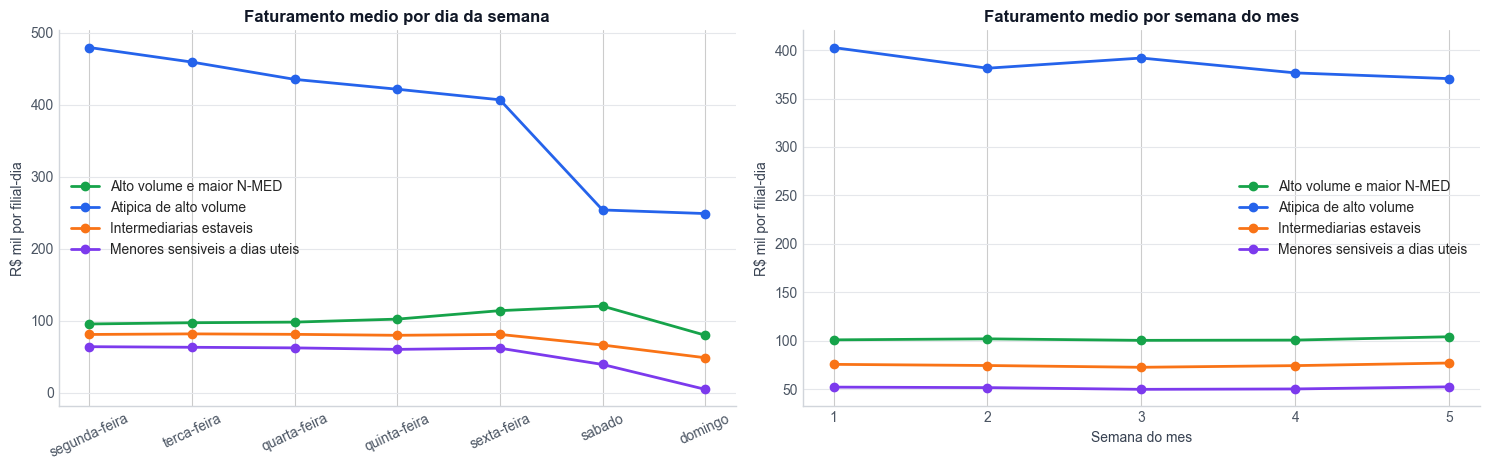

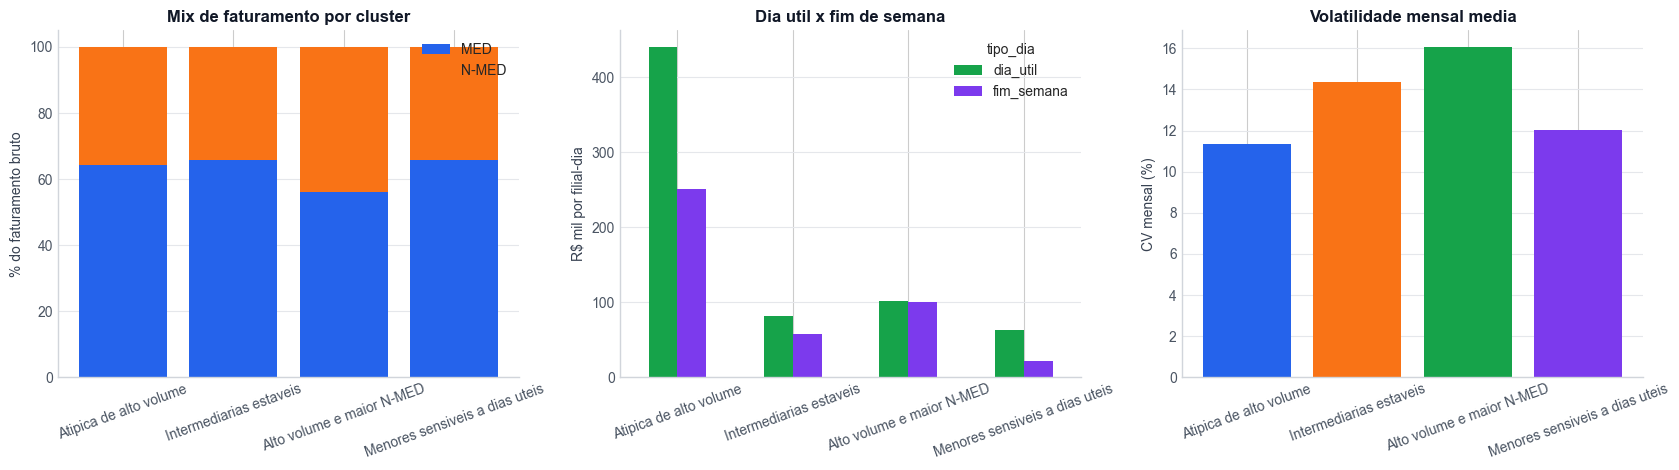

In [9]:
clusters_ordem = (
    perfil_clusters.sort_values("cluster_filial_id")["cluster_filial_nome"].tolist()
)
cores_base = [PALETA["azul"], PALETA["laranja"], PALETA["verde"], PALETA["roxo"], PALETA["cinza"], PALETA["vermelho"]]
cores_cluster = {
    cluster: cores_base[indice % len(cores_base)]
    for indice, cluster in enumerate(clusters_ordem)
}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

for cluster, dados in validacao_dia_semana.groupby("cluster_filial_nome"):
    dados = dados.sort_values("dia_semana_num")
    axes[0].plot(
        dados["dia_semana"],
        dados["faturamento_bruto_medio_dia"] / 1000,
        marker="o",
        linewidth=2,
        label=cluster,
        color=cores_cluster.get(cluster),
    )
axes[0].set_title("Faturamento medio por dia da semana")
axes[0].set_xlabel("")
axes[0].set_ylabel("R$ mil por filial-dia")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend()
limpar_eixo(axes[0])

for cluster, dados in validacao_semana_mes.groupby("cluster_filial_nome"):
    dados = dados.sort_values("semana_mes")
    axes[1].plot(
        dados["semana_mes"],
        dados["faturamento_bruto_medio_dia"] / 1000,
        marker="o",
        linewidth=2,
        label=cluster,
        color=cores_cluster.get(cluster),
    )
axes[1].set_title("Faturamento medio por semana do mes")
axes[1].set_xlabel("Semana do mes")
axes[1].set_ylabel("R$ mil por filial-dia")
axes[1].set_xticks(sorted(validacao_semana_mes["semana_mes"].unique()))
axes[1].legend()
limpar_eixo(axes[1])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

mix_plot = validacao_mix_categoria.sort_values("cluster_filial_id")
labels_mix = mix_plot["cluster_filial_nome"]
axes[0].bar(
    labels_mix,
    mix_plot["share_med_faturamento_total"] * 100,
    color=PALETA["azul"],
    label="MED",
)
axes[0].bar(
    labels_mix,
    mix_plot["share_n_med_faturamento_total"] * 100,
    bottom=mix_plot["share_med_faturamento_total"] * 100,
    color=PALETA["laranja"],
    label="N-MED",
)
axes[0].set_title("Mix de faturamento por cluster")
axes[0].set_xlabel("")
axes[0].set_ylabel("% do faturamento bruto")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()
limpar_eixo(axes[0])

fim_semana_plot = (
    validacao_fim_semana
    .pivot_table(
        index="cluster_filial_nome",
        columns="tipo_dia",
        values="faturamento_bruto_medio_dia",
        aggfunc="first",
    )
    .reindex(clusters_ordem)
    .fillna(0)
)
fim_semana_plot[["dia_util", "fim_semana"]].div(1000).plot(
    kind="bar",
    ax=axes[1],
    color=[PALETA["verde"], PALETA["roxo"]],
)
axes[1].set_title("Dia util x fim de semana")
axes[1].set_xlabel("")
axes[1].set_ylabel("R$ mil por filial-dia")
axes[1].tick_params(axis="x", rotation=20)
limpar_eixo(axes[1])

vol_plot = validacao_volatilidade_mensal.sort_values("cluster_filial_id")
axes[2].bar(
    vol_plot["cluster_filial_nome"],
    vol_plot["cv_faturamento_mensal_medio"] * 100,
    color=[cores_cluster.get(cluster) for cluster in vol_plot["cluster_filial_nome"]],
)
axes[2].set_title("Volatilidade mensal media")
axes[2].set_xlabel("")
axes[2].set_ylabel("CV mensal (%)")
axes[2].tick_params(axis="x", rotation=20)
limpar_eixo(axes[2])

plt.tight_layout()
plt.show()


## Visualizar perfil dos clusters

Resume tamanho, faturamento médio e ticket médio de cada grupo, destacando a filial `1521` como cluster especial.


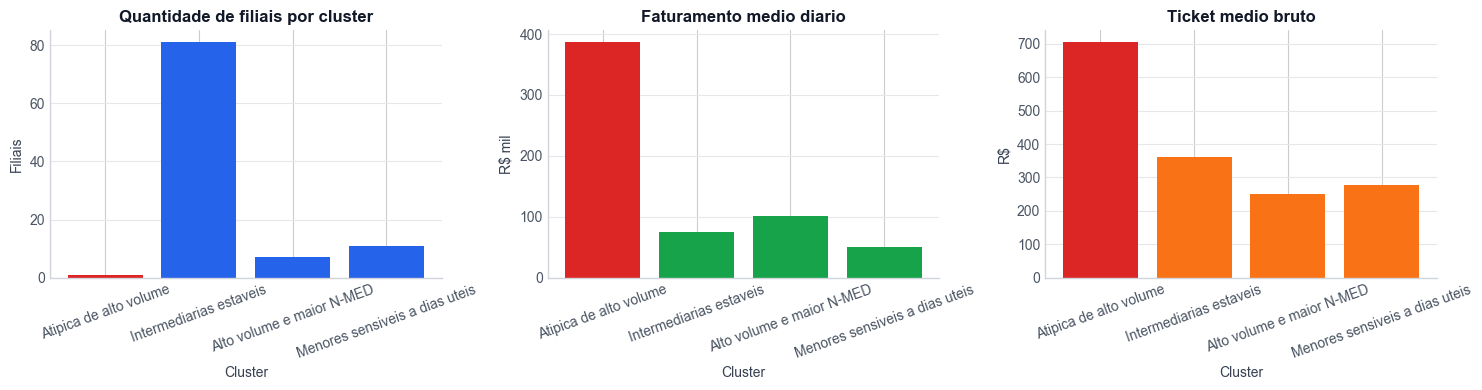

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

perfil_plot = perfil_clusters.sort_values("cluster_filial_id")
clusters_label = perfil_plot["cluster_filial_nome"]
cores_barras = np.where(perfil_plot["cluster_filial_id"].eq(-1), PALETA["vermelho"], PALETA["azul"])

axes[0].bar(clusters_label, perfil_plot["qtd_filiais"], color=cores_barras)
axes[0].set_title("Quantidade de filiais por cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Filiais")
axes[0].tick_params(axis="x", rotation=20)
limpar_eixo(axes[0])

axes[1].bar(
    clusters_label,
    perfil_plot["faturamento_bruto_medio_dia"] / 1000,
    color=np.where(perfil_plot["cluster_filial_id"].eq(-1), PALETA["vermelho"], PALETA["verde"]),
)
axes[1].set_title("Faturamento medio diario")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("R$ mil")
axes[1].tick_params(axis="x", rotation=20)
limpar_eixo(axes[1])

axes[2].bar(
    clusters_label,
    perfil_plot["ticket_medio_bruto_dia_medio"],
    color=np.where(perfil_plot["cluster_filial_id"].eq(-1), PALETA["vermelho"], PALETA["laranja"]),
)
axes[2].set_title("Ticket medio bruto")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("R$")
axes[2].tick_params(axis="x", rotation=20)
limpar_eixo(axes[2])

plt.tight_layout()
plt.show()


## Conclusão da segmentação

A segmentação final foi feita com a **Base B** (`semana_mes x dia_semana`) porque apresentou bom equilíbrio entre desempenho métrico e interpretabilidade. Ela reduz o ruído da granularidade `mes x semana x dia`, evita a explosão de colunas e gera grupos fáceis de explicar.

A filial `1521` foi mantida na base, mas tratada como cluster especial de alto volume. Essa decisão preserva a informação da filial sem deixar que ela distorça a leitura dos demais grupos.

O resultado final gera quatro perfis:

- `Intermediárias estáveis`
- `Alto volume e maior N-MED`
- `Menores sensíveis a dias úteis`
- `Atípica de alto volume`

Para a etapa de modelagem, o arquivo principal é `cluster_filial_modelagem_V2.parquet`, que permite anexar o cluster à base diária por `codigo_filial`.


## Salvar checkpoints finais

Salva apenas os artefatos finais necessários para análise e modelagem.


In [11]:
caminhos_saida = {
    "cluster_filial_modelagem": BASE_V2 / CHECKPOINTS_CLUSTER["cluster_filial_modelagem"],
    "perfil_clusters": BASE_V2 / CHECKPOINTS_CLUSTER["perfil_clusters"],
}

cluster_filial_modelagem.to_parquet(caminhos_saida["cluster_filial_modelagem"], index=False)
perfil_clusters.to_parquet(caminhos_saida["perfil_clusters"], index=False)

display(pd.Series({nome: str(caminho) for nome, caminho in caminhos_saida.items()}, name="checkpoint_salvo").to_frame())


,arquivo_salvo
metricas,E:\trabalhos\PROJ3- Panvel\Base_V2\cluster_met...
resumo_bases,E:\trabalhos\PROJ3- Panvel\Base_V2\cluster_res...
filiais_clusterizadas,E:\trabalhos\PROJ3- Panvel\Base_V2\filiais_clu...
cluster_filial_modelagem,E:\trabalhos\PROJ3- Panvel\Base_V2\cluster_fil...
perfil_clusters,E:\trabalhos\PROJ3- Panvel\Base_V2\perfil_clus...
validacao_dia_semana,E:\trabalhos\PROJ3- Panvel\Base_V2\cluster_val...
validacao_semana_mes,E:\trabalhos\PROJ3- Panvel\Base_V2\cluster_val...
validacao_mix_categoria,E:\trabalhos\PROJ3- Panvel\Base_V2\cluster_val...
validacao_fim_semana,E:\trabalhos\PROJ3- Panvel\Base_V2\cluster_val...
validacao_volatilidade_mensal,E:\trabalhos\PROJ3- Panvel\Base_V2\cluster_val...
